### Why unequal variance is plausible
Edit the numbers marked `👈` and re-run.

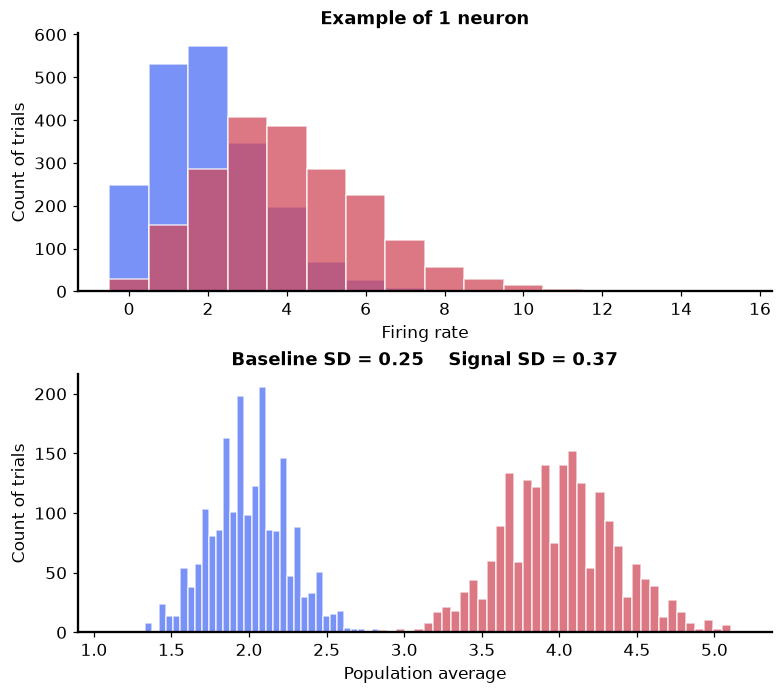

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

n_neurons     = 30      # 👈 neurons averaged over
ntrials       = 2000
baseline_rate = 2       # 👈 firing rate on signal-absent trials
signal_rate   = 4       # 👈 firing rate on signal-present trials (higher mean -> higher variance)

rng = np.random.default_rng()
fr_baseline = rng.poisson(baseline_rate, (n_neurons, ntrials))
fr_signal   = rng.poisson(signal_rate,   (n_neurons, ntrials))
est_absent  = fr_baseline.mean(axis=0)
est_present = fr_signal.mean(axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.2), constrained_layout=True)
ax1.hist(fr_baseline[0], bins=np.arange(fr_baseline.max() + 2) - 0.5, color=NOISE,  alpha=0.75, edgecolor="white")
ax1.hist(fr_signal[0],   bins=np.arange(fr_signal.max()   + 2) - 0.5, color=SIGNAL, alpha=0.75, edgecolor="white")
ax1.set(xlabel="Firing rate", ylabel="Count of trials", title="Example of 1 neuron")

ax2.hist(est_absent,  bins=40, color=NOISE,  alpha=0.75, edgecolor="white")
ax2.hist(est_present, bins=40, color=SIGNAL, alpha=0.75, edgecolor="white")
ax2.set(xlabel="Population average", ylabel="Count of trials",
        title=f"Baseline SD = {est_absent.std():.2g}    Signal SD = {est_present.std():.2g}")
plt.show()
